In [1]:
import os, glob, urllib.request
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO

# 한글 폰트 패치 (Windows: 맑은 고딕)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# PIL용 한글 폰트 로드 (없으면 기본 폰트로 대체)
try:
    KFONT = ImageFont.truetype("C:/Windows/Fonts/malgun.ttf", 22)
    KFONT_BIG = ImageFont.truetype("C:/Windows/Fonts/malgunbd.ttf", 28)
except OSError:
    KFONT = ImageFont.load_default()
    KFONT_BIG = KFONT
    print("⚠️ 맑은 고딕 폰트를 찾지 못해 기본 폰트로 대체합니다.")

# COCO 클래스명 → 한글 라벨 매핑 (자주 등장하는 것 위주)
KOR_NAMES = {
    'person': '사람', 'bicycle': '자전거', 'car': '자동차', 'motorcycle': '오토바이',
    'airplane': '비행기', 'bus': '버스', 'train': '기차', 'truck': '트럭', 'boat': '보트',
    'traffic light': '신호등', 'stop sign': '정지표지판', 'bench': '벤치',
    'bird': '새', 'cat': '고양이', 'dog': '강아지', 'horse': '말',
    'backpack': '배낭', 'umbrella': '우산', 'handbag': '핸드백', 'tie': '넥타이',
    'suitcase': '여행가방', 'sports ball': '공', 'skateboard': '스케이트보드',
    'bottle': '병', 'wine glass': '와인잔', 'cup': '컵', 'fork': '포크', 'knife': '나이프',
    'spoon': '숟가락', 'bowl': '그릇', 'banana': '바나나', 'apple': '사과',
    'sandwich': '샌드위치', 'orange': '오렌지', 'pizza': '피자', 'donut': '도넛', 'cake': '케이크',
    'chair': '의자', 'couch': '소파', 'potted plant': '화분', 'bed': '침대',
    'dining table': '식탁', 'toilet': '변기', 'tv': 'TV', 'laptop': '노트북',
    'mouse': '마우스', 'remote': '리모컨', 'keyboard': '키보드', 'cell phone': '휴대폰',
    'microwave': '전자레인지', 'oven': '오븐', 'refrigerator': '냉장고',
    'book': '책', 'clock': '시계', 'vase': '꽃병', 'teddy bear': '곰인형',
}

def kname(eng):
    # 매핑에 없으면 영문 그대로 반환
    return KOR_NAMES.get(eng, eng)

print("환경 준비 완료")

환경 준비 완료


In [2]:
# 이미지 다운로드 (이미 있으면 건너뜀)
IMAGE_URLS = {
    'bus.jpg':    'https://ultralytics.com/images/bus.jpg',
    'zidane.jpg': 'https://ultralytics.com/images/zidane.jpg',
    'cats.jpg':   'http://images.cocodataset.org/val2017/000000039769.jpg',
}

os.makedirs('scenes', exist_ok=True)

for fname, url in IMAGE_URLS.items():
    path = os.path.join('scenes', fname)
    try:
        already = glob.glob(path)
        if not already:
            urllib.request.urlretrieve(url, path)
            print(f" 다운로드 완료: {fname}")
        else:
            print(f" 이미 존재: {fname}")
    except Exception as e:
        print(f" {fname} 다운로드 실패: {e}")

# 확보된 사건 현장 목록
scene_files = sorted(glob.glob('scenes/*.jpg'))
print(f"\n 확보된 사건 현장: {len(scene_files)}곳 → {scene_files}")

 이미 존재: bus.jpg
 이미 존재: zidane.jpg
 이미 존재: cats.jpg

 확보된 사건 현장: 4곳 → ['scenes\\bus.jpg', 'scenes\\cats.jpg', 'scenes\\train.jpg', 'scenes\\zidane.jpg']


In [3]:
# YOLO11 nano 모델 로드 (최초 실행 시 자동 다운로드)
model = YOLO('yolo11n.pt')

n_classes = len(model.names)
print(f" 탐정 고용 완료! 이 탐정은 {n_classes}종류의 물체를 알아봅니다.")
print("예시:", [kname(model.names[i]) for i in range(10)])

 탐정 고용 완료! 이 탐정은 80종류의 물체를 알아봅니다.
예시: ['사람', '자전거', '자동차', '오토바이', '비행기', '버스', '기차', '트럭', '보트', '신호등']


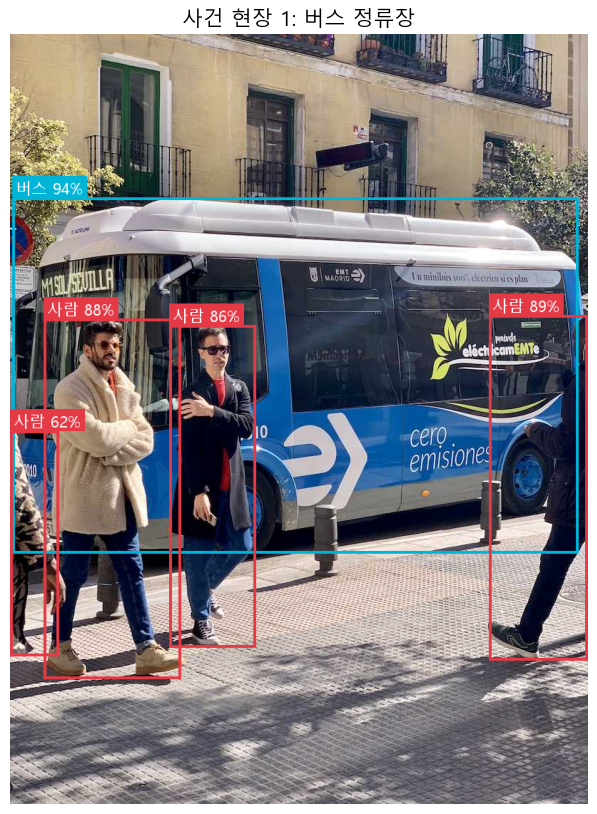

검출된 객체 수: 5개


In [4]:
# 클래스별 고정 색상 팔레트
PALETTE = ['#E63946', '#457B9D', '#2A9D8F', '#F4A261', '#9B5DE5',
           '#00B4D8', '#EF476F', '#06D6A0', '#FFD166', '#8338EC']

def detect_and_draw(img_path, conf=0.4):
    # 객체 검출 수행 후 한글 라벨 박스를 그린 PIL 이미지와 결과 반환
    result = model(img_path, conf=conf, verbose=False)[0]
    img = Image.open(img_path).convert('RGB')
    draw = ImageDraw.Draw(img)

    for box in result.boxes:
        cls_id = int(box.cls[0])
        score = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        label = f"{kname(model.names[cls_id])} {score:.0%}"
        color = PALETTE[cls_id % len(PALETTE)]

        draw.rectangle([x1, y1, x2, y2], outline=color, width=4)
        tw = draw.textlength(label, font=KFONT)
        draw.rectangle([x1, y1 - 30, x1 + tw + 10, y1], fill=color)
        draw.text((x1 + 5, y1 - 28), label, font=KFONT, fill='white')

    return img, result

# 첫 번째 현장: 버스 정류장
img, result = detect_and_draw('scenes/bus.jpg')

plt.figure(figsize=(9, 10))
plt.imshow(img)
plt.title('사건 현장 1: 버스 정류장', fontsize=15)
plt.axis('off')
plt.show()

print(f"검출된 객체 수: {len(result.boxes)}개")

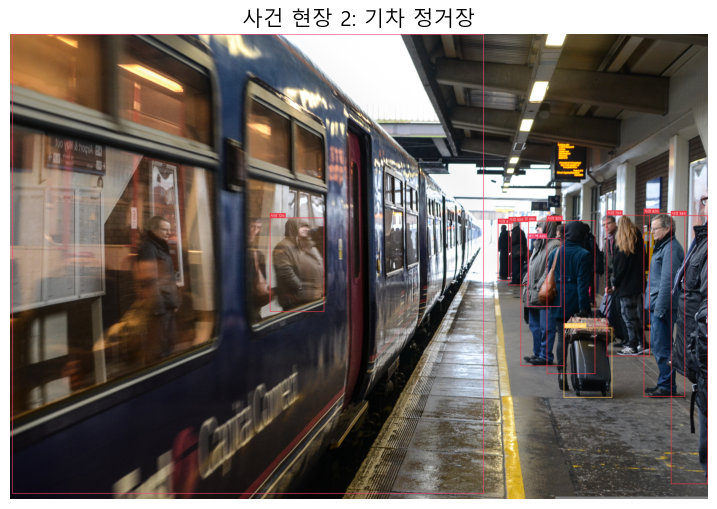

검출된 객체 수: 11개


In [5]:
img, result = detect_and_draw('scenes/train.jpg')

plt.figure(figsize=(9, 10))
plt.imshow(img)
plt.title('사건 현장 2: 기차 정거장', fontsize=15)
plt.axis('off')
plt.show()

print(f"검출된 객체 수: {len(result.boxes)}개")